# Double QD Removed Screening

This notebook is a focused workflow for rerunning the 2D double quantum dot simulation with the removed-screening contact and diagnosing whether the chosen `fermi_hole` bias avoids parasitic hole accumulation in the SiGe cap. The main target is to keep the HH band edge at the oxide interface from crossing the hole Fermi level while preserving the intended accumulation in the Ge quantum well.

## 0. Setup

### - Imports

Import the libraries needed to run the simulation, reuse existing runs, and inspect the most relevant electrostatic and HH quantum outputs.

In [1]:
from pathlib import Path
import re
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'src').exists() and (path / 'notebooks').exists()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import nextnanopp_tools as nnt
nnt = importlib.reload(nnt)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 4.5)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)


### - Input Config

Set the input file, the trial value of the removed-screening `fermi_hole` bias, the run-tag behavior, and the line cuts that are most useful for this troubleshooting study. The input file now exposes `$V_remove_surface_charge`, so the notebook can pass new trial values directly through `nextnanopy` when you rerun. Set `INTERACTIVE_LINECUTS = True` to make the 1D `.dat` plots and extracted line cuts interactive for zooming, read-off, and trace toggling. Set `SHOW_LANDMARKS = True` to overlay dashed device landmarks on 2D maps and on matching 1D cuts.

In [2]:
INPUT_PATH = REPO_ROOT / 'configs/robert_inputs/double_qd/2d/Double_Quantum_Dot_2D_no_screening_charge.in'
RUNS_ROOT = REPO_ROOT / 'runs'

TRIAL_REMOVE_SURFACE_CHARGE_BIAS = -0.70
APPLY_BIAS_OVERRIDE = True

AUTO_TAG_WITH_BIAS = True
RUN_TAG = None
FORCE_RERUN = False
REUSE_LATEST_MATCHING_RUN = True

BIAS_INDEX = 0
REGION_CUT = '1d_z_BG2'
STANDARD_CUTS = ['1d_x_QD', '1d_z_BG2', '1d_z_PG1', '1d_z_PG2']

SURFACE_LINECUT_AXIS = 'x'
SURFACE_LINECUT_COORDS = {'z': 100.5}

QW_LINECUT_AXIS = 'x'
QW_LINECUT_COORDS = {'z': -4.0} # quantum density seems to peak at -4nm; otherwise expected depth of 2DHG is -2nm

INTERACTIVE_PLANES = False
INTERACTIVE_LINECUTS = False
SHOW_LANDMARKS = True

QUANTUM_REGION = 'c-Ge_QW'
QUANTUM_BAND = 'HH'
QUANTUM_KPOINT = 'k00000'
QUANTUM_PROBABILITY_STATE = 1
QUANTUM_PROBABILITY_STATES = (1, 2, 3)

def format_bias_tag(value: float) -> str:
    sign = 'p' if value >= 0 else 'm'
    magnitude = f"{abs(value):.3f}".replace('.', 'p')
    return f'remove_surface_charge_{sign}{magnitude}V'

ACTIVE_RUN_TAG = RUN_TAG
if ACTIVE_RUN_TAG is None and AUTO_TAG_WITH_BIAS:
    ACTIVE_RUN_TAG = format_bias_tag(TRIAL_REMOVE_SURFACE_CHARGE_BIAS)

INPUT_VARIABLE_OVERRIDES = None
if APPLY_BIAS_OVERRIDE:
    INPUT_VARIABLE_OVERRIDES = {'V_remove_surface_charge': TRIAL_REMOVE_SURFACE_CHARGE_BIAS}

EXISTING_RUNS = nnt.find_runs_for_input(RUNS_ROOT, INPUT_PATH)
MATCHING_RUNS = [
    run for run in EXISTING_RUNS
    if ACTIVE_RUN_TAG is None or ACTIVE_RUN_TAG in run.name
]

config_summary = pd.Series({
    'INPUT_PATH': str(INPUT_PATH),
    'TRIAL_REMOVE_SURFACE_CHARGE_BIAS [V]': TRIAL_REMOVE_SURFACE_CHARGE_BIAS,
    'APPLY_BIAS_OVERRIDE': APPLY_BIAS_OVERRIDE,
    'ACTIVE_RUN_TAG': ACTIVE_RUN_TAG,
    'FORCE_RERUN': FORCE_RERUN,
    'REUSE_LATEST_MATCHING_RUN': REUSE_LATEST_MATCHING_RUN,
    'MATCHING_RUNS_FOUND': len(MATCHING_RUNS),
    'SURFACE_LINECUT': f"{SURFACE_LINECUT_AXIS} at {SURFACE_LINECUT_COORDS}",
    'QW_LINECUT': f"{QW_LINECUT_AXIS} at {QW_LINECUT_COORDS}",
    'INTERACTIVE_PLANES': INTERACTIVE_PLANES,
    'INTERACTIVE_LINECUTS': INTERACTIVE_LINECUTS,
    'SHOW_LANDMARKS': SHOW_LANDMARKS,
})
display(config_summary.to_frame('value'))

if MATCHING_RUNS:
    print('Most recent matching runs:')
    for run in MATCHING_RUNS[-5:]:
        print(' -', run)
else:
    print('No existing runs match the current input stem and tag.')


,value
INPUT_PATH,/Users/robertjovanov/code/qpu-design-automatio...
TRIAL_REMOVE_SURFACE_CHARGE_BIAS [V],-0.7
APPLY_BIAS_OVERRIDE,True
ACTIVE_RUN_TAG,remove_surface_charge_m0p700V
FORCE_RERUN,False
REUSE_LATEST_MATCHING_RUN,True
MATCHING_RUNS_FOUND,3
SURFACE_LINECUT,x at {'z': 100.5}
QW_LINECUT,x at {'z': -4.0}
INTERACTIVE_PLANES,False


Most recent matching runs:
 - /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_2D_no_screening_charge__20260421_193359__remove_surface_charge_m0p700V
 - /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_2D_no_screening_charge__20260421_201555__remove_surface_charge_m0p700V
 - /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Double_Quantum_Dot_2D_no_screening_charge__20260421_204400__remove_surface_charge_m0p700V


### - Helper functions

Define a few notebook-local helpers to reuse the plotting wrappers, extract a manual line cut from a 2D plane, and loop over the standard diagnostic cuts without repeating boilerplate.

In [3]:
def _marker_label(marker):
    if isinstance(marker, dict):
        return marker.get('label', '')
    return marker[1] if len(marker) > 1 else ''


def _marker_value(marker):
    if isinstance(marker, dict):
        return float(marker['value'])
    return float(marker[0])


def add_plotly_x_markers(fig, markers):
    for marker in markers or []:
        fig.add_vline(
            x=_marker_value(marker),
            line_dash=marker.get('dash', marker.get('linestyle', 'dash')) if isinstance(marker, dict) else 'dash',
            line_color=marker.get('color', 'rgba(80,80,80,0.85)') if isinstance(marker, dict) else 'rgba(80,80,80,0.85)',
            line_width=marker.get('width', marker.get('linewidth', 1.3)) if isinstance(marker, dict) else 1.3,
            opacity=marker.get('alpha', 0.85) if isinstance(marker, dict) else 0.85,
            annotation_text=_marker_label(marker) or None,
            annotation_position='top left',
        )


def add_matplotlib_x_markers(ax, markers):
    linestyle_map = {'dash': '--', 'dot': ':', 'solid': '-', 'dashdot': '-.'}
    for marker in markers or []:
        color = marker.get('color', '0.35') if isinstance(marker, dict) else '0.35'
        linestyle = marker.get('linestyle', marker.get('dash', '--')) if isinstance(marker, dict) else '--'
        linestyle = linestyle_map.get(linestyle, linestyle)
        value = _marker_value(marker)
        alpha = marker.get('alpha', 0.85) if isinstance(marker, dict) else 0.85
        ax.axvline(value, color=color, linestyle=linestyle, linewidth=1.3, alpha=alpha)
        label = _marker_label(marker)
        if label:
            ax.text(
                value,
                0.98,
                label,
                transform=ax.get_xaxis_transform(),
                rotation=90,
                va='top',
                ha='right',
                color=color,
                fontsize=8,
                alpha=alpha,
            )


def parse_contact_rectangles_from_simulation_input(run_root):
    text = (Path(run_root) / 'simulation_input.txt').read_text()
    origin_match = re.search(
        r'set_origin\s*\{.*?x\s*=\s*([-+0-9.eE]+).*?y\s*=\s*([-+0-9.eE]+).*?\}',
        text,
        flags=re.S,
    )
    origin_x = float(origin_match.group(1)) if origin_match else 0.0
    origin_y = float(origin_match.group(2)) if origin_match else 0.0
    pattern = re.compile(
        r'region\s*\{.*?rectangle\s*\{.*?'
        r'x\s*=\s*\[\s*([-+0-9.eE]+)\s*,\s*([-+0-9.eE]+)\s*\].*?'
        r'y\s*=\s*\[\s*([-+0-9.eE]+)\s*,\s*([-+0-9.eE]+)\s*\].*?'
        r'\}.*?contact\s*\{.*?name\s*=\s*"([^"]+)"',
        flags=re.S,
    )
    records = []
    for match in pattern.finditer(text):
        x_left, x_right, y_bottom, y_top = map(float, match.groups()[:4])
        name = match.group(5)
        records.append({
            'name': name,
            'x_left': x_left - origin_x,
            'x_right': x_right - origin_x,
            'x_center': 0.5 * (x_left + x_right) - origin_x,
            'z_bottom': y_bottom - origin_y,
            'z_top': y_top - origin_y,
            'z_center': 0.5 * (y_bottom + y_top) - origin_y,
        })
    return pd.DataFrame(records)


def build_layer_landmarks(run_root, *, cut='1d_z_BG2'):
    structure_map = nnt.build_region_material_map(run_root, cut=cut).copy()
    structure_map = structure_map.sort_values('coord_min')
    ge_rows = structure_map[
        structure_map['material_name'].str.fullmatch('Ge', case=False, na=False)
        & (structure_map['thickness_nm'] > 2)
    ]
    if ge_rows.empty:
        return pd.DataFrame(), []
    ge_qw = ge_rows.iloc[(ge_rows['thickness_nm'] - ge_rows['thickness_nm'].max()).abs().argmin()]
    above_qw = structure_map[
        (structure_map['coord_min'] > ge_qw['coord_max'])
        & structure_map['material_name'].str.contains('Si', na=False)
    ].sort_values('coord_min')
    cap_top = above_qw.iloc[0]['coord_max'] if not above_qw.empty else np.nan
    rows = [
        {'kind': 'layer', 'name': 'Ge QW bottom', 'axis': 'z', 'value': float(ge_qw['coord_min'])},
        {'kind': 'layer', 'name': 'Ge QW top', 'axis': 'z', 'value': float(ge_qw['coord_max'])},
    ]
    if np.isfinite(cap_top):
        rows.append({'kind': 'layer', 'name': 'top SiGe cap', 'axis': 'z', 'value': float(cap_top)})
    df = pd.DataFrame(rows)
    markers = [
        {
            'value': row.value,
            'label': row.name,
            'color': '#0B78D0' if 'Ge QW' in row.name else '#E67E22',
            'dash': 'dash',
            'linestyle': 'dash',
            'alpha': 0.9,
        }
        for row in df.itertuples(index=False)
    ]
    return df, markers


def build_gate_landmarks(run_root, gate_names=('BG1', 'PG1', 'BG2', 'PG2', 'BG3')):
    contacts = parse_contact_rectangles_from_simulation_input(run_root)
    if contacts.empty:
        return contacts, []
    gates = contacts[contacts['name'].isin(gate_names)].copy()
    gates['gate_order'] = gates['name'].map({name: idx for idx, name in enumerate(gate_names)})
    gates = gates.sort_values(['gate_order', 'x_center'])
    markers = []
    for row in gates.itertuples(index=False):
        is_plunger = str(row.name).startswith('PG')
        markers.append({
            'value': float(row.x_center),
            'label': str(row.name),
            'color': '#D62728' if is_plunger else '#2C7FB8',
            'dash': 'dash',
            'linestyle': 'dash',
            'alpha': 0.85,
        })
    return gates.drop(columns=['gate_order']), markers


def active_markers(markers):
    return list(markers) if SHOW_LANDMARKS else []


def markers_for_axis(axis):
    axis = str(axis).lower()
    if axis.startswith('x'):
        return active_markers(globals().get('GATE_X_MARKERS', []))
    if axis.startswith('z') or axis.startswith('y'):
        return active_markers(globals().get('LAYER_Z_MARKERS', []))
    return []


def markers_for_cut(cut):
    cut = str(cut).lower()
    if '_x_' in cut or cut.startswith('1d_x'):
        return markers_for_axis('x')
    if '_z_' in cut or cut.startswith('1d_z'):
        return markers_for_axis('z')
    return []


def plot_selected_dataset_linecut(
    path,
    *,
    variable=None,
    axis='x',
    fixed_coords=None,
    log10=False,
    title=None,
    prefer_nextnanopy=True,
    interactive=False,
    markers=None,
):
    dataset = nnt.load_output_file(path, prefer_nextnanopy=prefer_nextnanopy)
    line = nnt.extract_linecut(
        dataset,
        variable=variable,
        axis=axis,
        fixed_coords=fixed_coords or {},
    )
    values = np.asarray(line['values'], dtype=float)
    ylabel = line['variable'].label or line['variable'].name
    if log10:
        values = np.where(values > 0, np.log10(values), np.nan)
        ylabel = f'log10({ylabel})'

    plot_title = title or f"{Path(path).name} along {axis} at {line['chosen_coords']}"
    if interactive:
        import plotly.graph_objects as go

        fig = go.Figure()
        fig.add_trace(
            go.Scatter(
                x=line['axis'],
                y=values,
                mode='lines',
                name=line['variable'].name,
            )
        )
        fig.update_layout(
            title=plot_title,
            xaxis_title=line['axis_label'],
            yaxis_title=ylabel,
            template='plotly_white',
            height=450,
        )
        add_plotly_x_markers(fig, markers)
        display(fig)
    else:
        fig, ax = plt.subplots(figsize=(10, 4.2))
        ax.plot(line['axis'], values, lw=2)
        ax.set_xlabel(line['axis_label'])
        ax.set_ylabel(ylabel)
        ax.set_title(plot_title)
        ax.grid(alpha=0.25)
        add_matplotlib_x_markers(ax, markers)
        plt.show()
    return line


def show_bias_plane_with_linecut(
    run_root,
    quantity,
    *,
    variable=None,
    interactive=False,
    interactive_linecut=False,
    line_axis='x',
    line_coords=None,
    log10=False,
    bias=0,
):
    path = nnt.resolve_bias_output_file(
        run_root,
        quantity,
        bias=bias,
        preferred_extensions=('fld',),
    )
    nnt.plot_bias_plane(
        run_root,
        quantity,
        bias=bias,
        variable=variable,
        interactive=interactive,
        log10=log10,
        x_markers=markers_for_axis('x'),
        y_markers=markers_for_axis('z'),
    )
    if not interactive:
        plt.show()
    return plot_selected_dataset_linecut(
        path,
        variable=variable,
        axis=line_axis,
        fixed_coords=line_coords or {},
        log10=log10,
        title=f"{path.name} line cut along {line_axis} at {line_coords or {}}",
        interactive=interactive_linecut,
        markers=markers_for_axis(line_axis),
    )


def show_quantum_plane_with_linecut(
    run_root,
    *,
    quantity='density',
    region='c-Ge_QW',
    band='HH',
    variable=None,
    interactive=False,
    interactive_linecut=False,
    line_axis='x',
    line_coords=None,
    log10=False,
    bias=0,
):
    path = nnt.resolve_quantum_output_file(
        run_root,
        quantity,
        region=region,
        band=band,
        bias=bias,
        preferred_extensions=('fld',),
    )
    nnt.plot_quantum_plane(
        run_root,
        quantity=quantity,
        region=region,
        band=band,
        bias=bias,
        variable=variable,
        interactive=interactive,
        log10=log10,
        x_markers=markers_for_axis('x'),
        y_markers=markers_for_axis('z'),
    )
    if not interactive:
        plt.show()
    return plot_selected_dataset_linecut(
        path,
        variable=variable,
        axis=line_axis,
        fixed_coords=line_coords or {},
        log10=log10,
        title=f"{path.name} line cut along {line_axis} at {line_coords or {}}",
        interactive=interactive_linecut,
        markers=markers_for_axis(line_axis),
    )


def plot_bias_linecuts_for_cuts(
    run_root,
    quantity,
    cuts,
    *,
    variables=None,
    yscale='linear',
    bias=0,
    interactive=False,
):
    for cut in cuts:
        try:
            nnt.plot_bias_linecut(
                run_root,
                quantity,
                cut=cut,
                bias=bias,
                variables=variables,
                interactive=interactive,
                yscale=yscale,
                markers=markers_for_cut(cut),
            )
            if not interactive:
                plt.show()
        except FileNotFoundError:
            print(f'Skipping missing {quantity} cut: {cut}')


def plot_quantum_density_linecuts_for_cuts(
    run_root,
    cuts,
    *,
    region='c-Ge_QW',
    band='HH',
    bias=0,
    yscale='linear',
    interactive=False,
):
    for cut in cuts:
        try:
            nnt.plot_quantum_linecut(
                run_root,
                quantity='density',
                cut=cut,
                region=region,
                band=band,
                bias=bias,
                interactive=interactive,
                yscale=yscale,
                markers=markers_for_cut(cut),
            )
            if not interactive:
                plt.show()
        except FileNotFoundError:
            print(f'Skipping missing quantum density cut: {cut}')


def plot_quantum_probability_linecuts_for_cuts(
    run_root,
    cuts,
    *,
    states=(1, 2, 3),
    region='c-Ge_QW',
    band='HH',
    kpoint='k00000',
    bias=0,
    interactive=False,
):
    # Refresh the helper module in case this notebook kernel still holds an older import.
    global nnt
    nnt = importlib.reload(nnt)

    for cut in cuts:
        try:
            nnt.plot_quantum_probabilities_linecut(
                run_root,
                cut=cut,
                states=states,
                region=region,
                band=band,
                kpoint=kpoint,
                bias=bias,
                interactive=interactive,
                markers=markers_for_cut(cut),
            )
            if not interactive:
                plt.show()
        except FileNotFoundError:
            print(f'Skipping missing quantum probability cut: {cut}')


## 1. 2D Simulation

Run the simulation with the removed-screening configuration above. If a matching tagged run already exists, the notebook can reuse it instead of launching a new one.

In [4]:
if FORCE_RERUN or not MATCHING_RUNS or not REUSE_LATEST_MATCHING_RUN:
    print('Running simulation...')
    inp = nnt.load_input_file(INPUT_PATH)
    inp = nnt.run_input_file(
        inp,
        output_root=RUNS_ROOT,
        tag=ACTIVE_RUN_TAG,
        variables=INPUT_VARIABLE_OVERRIDES,
        show_log=False,
        convergenceCheck=True,
    )
    RUN_ROOT = nnt.get_output_directory(inp)
else:
    print('Reusing latest matching run.')
    RUN_ROOT = MATCHING_RUNS[-1]

RUN_ROOT = nnt.resolve_run_root(RUN_ROOT)
RUN_PATHS = nnt.get_run_paths(RUN_ROOT)
BIAS0 = nnt.get_bias_dir(RUN_ROOT, bias=BIAS_INDEX)

run_summary = pd.Series({
    'RUN_ROOT': str(RUN_ROOT),
    'RUN_NAME': RUN_ROOT.name,
    'BIAS_FOLDER': str(BIAS0),
    'job_done': (RUN_ROOT / 'job_done.txt').exists(),
    'TRIAL_REMOVE_SURFACE_CHARGE_BIAS [V]': TRIAL_REMOVE_SURFACE_CHARGE_BIAS,
    'ACTIVE_RUN_TAG': ACTIVE_RUN_TAG,
})
display(run_summary.to_frame('value'))


Reusing latest matching run.


,value
RUN_ROOT,/Users/robertjovanov/code/qpu-design-automatio...
RUN_NAME,Double_Quantum_Dot_2D_no_screening_charge__202...
BIAS_FOLDER,/Users/robertjovanov/code/qpu-design-automatio...
job_done,True
TRIAL_REMOVE_SURFACE_CHARGE_BIAS [V],-0.7
ACTIVE_RUN_TAG,remove_surface_charge_m0p700V


### - Plot landmarks

Build optional overlay markers from the completed run: horizontal layer markers for the Ge QW and top of the SiGe cap, and vertical gate-center markers for the plunger and barrier gates.

In [5]:
LAYER_LANDMARKS, LAYER_Z_MARKERS = build_layer_landmarks(RUN_ROOT, cut=REGION_CUT)
GATE_LANDMARKS, GATE_X_MARKERS = build_gate_landmarks(RUN_ROOT)

if SHOW_LANDMARKS:
    print('Layer landmarks used for z-axis markers:')
    display(LAYER_LANDMARKS)
    print('Gate landmarks used for x-axis markers:')
    display(GATE_LANDMARKS[['name', 'x_left', 'x_right', 'x_center', 'z_bottom', 'z_top']])
else:
    print('Landmark overlays are disabled. Set SHOW_LANDMARKS = True to enable them.')


Layer landmarks used for z-axis markers:


,kind,name,axis,value
0,layer,Ge QW bottom,z,-14.75
1,layer,Ge QW top,z,-0.25
2,layer,top SiGe cap,z,99.95


Gate landmarks used for x-axis markers:


,name,x_left,x_right,x_center,z_bottom,z_top
5,BG1,1040.0,1080.0,1060.0,108.0,138.0
6,PG1,1100.0,1200.0,1150.0,143.0,173.0
7,BG2,1220.0,1260.0,1240.0,108.0,138.0
8,PG2,1280.0,1380.0,1330.0,143.0,173.0
9,BG3,1400.0,1440.0,1420.0,108.0,138.0


### - Accumulation diagnostics

Start with the quickest checks: the integrated hole density by region and material, then the charge totals from `total_charges.txt`.

,integrated_region_index,structure_region_index,material_name,coord_min,coord_max,thickness_nm
0,3,2,Ge,-14.75,-0.25,14.5
1,4,3,Si(x)Ge(1-x),0.25,99.95,99.7
2,5,4,Si(x)Ge(1-x),100.05,100.95,0.9


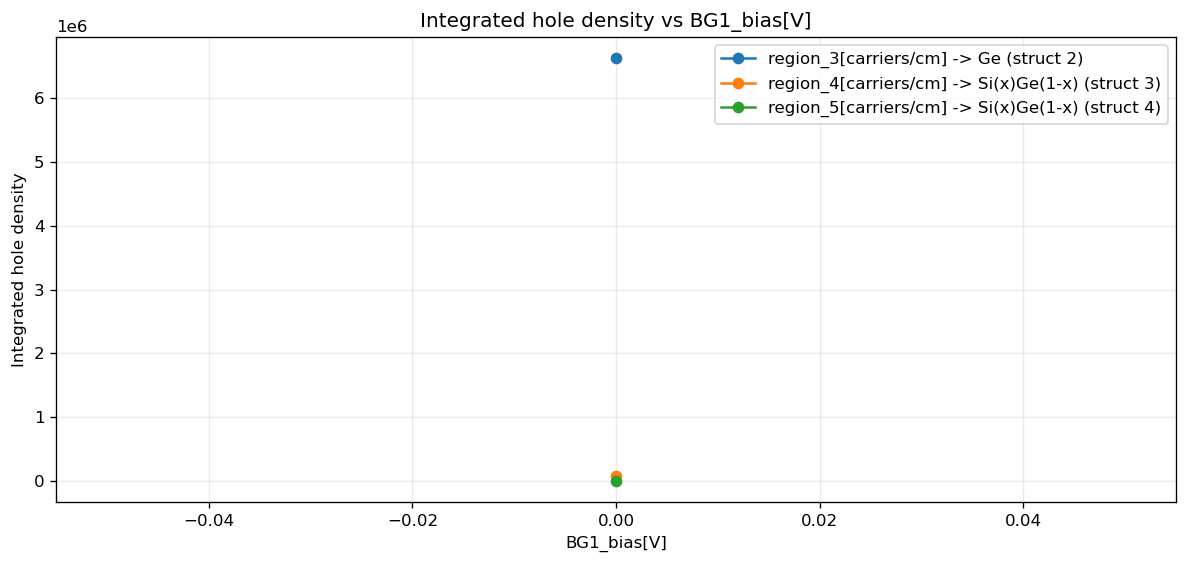

In [7]:
integrated_map = nnt.map_integrated_density_regions(RUN_ROOT, cut=REGION_CUT)
display(
    integrated_map[
        [
            'integrated_region_index',
            'structure_region_index',
            'material_name',
            'coord_min',
            'coord_max',
            'thickness_nm',
        ]
    ]
)

nnt.plot_integrated_density_hole(
    RUN_ROOT,
    interactive=False,
    label_with_materials=True,
    cut=REGION_CUT,
)
plt.show()


In [8]:
total_charges = nnt.read_total_charges(BIAS0)
display(total_charges.style.format({'value': '{:.3e}'}))


,quantity,value,unit
0,electrons,-1.177e-298,e/cm
1,holes,6.652e+06,e/cm
2,ionized donors,0.000e+00,e/cm
3,ionized acceptors,-0.000e+00,e/cm
4,fixed charges,0.000e+00,e/cm
5,polarization_total,0.000e+00,e/cm
6,polarization_piezo,0.000e+00,e/cm
7,sum,6.652e+06,e/cm


### - Potential

Use the 2D potential to inspect the full landscape, then extract a horizontal line cut near the oxide interface. The explicit 1D output cuts below are the standard quick checks through the QD and gate locations.

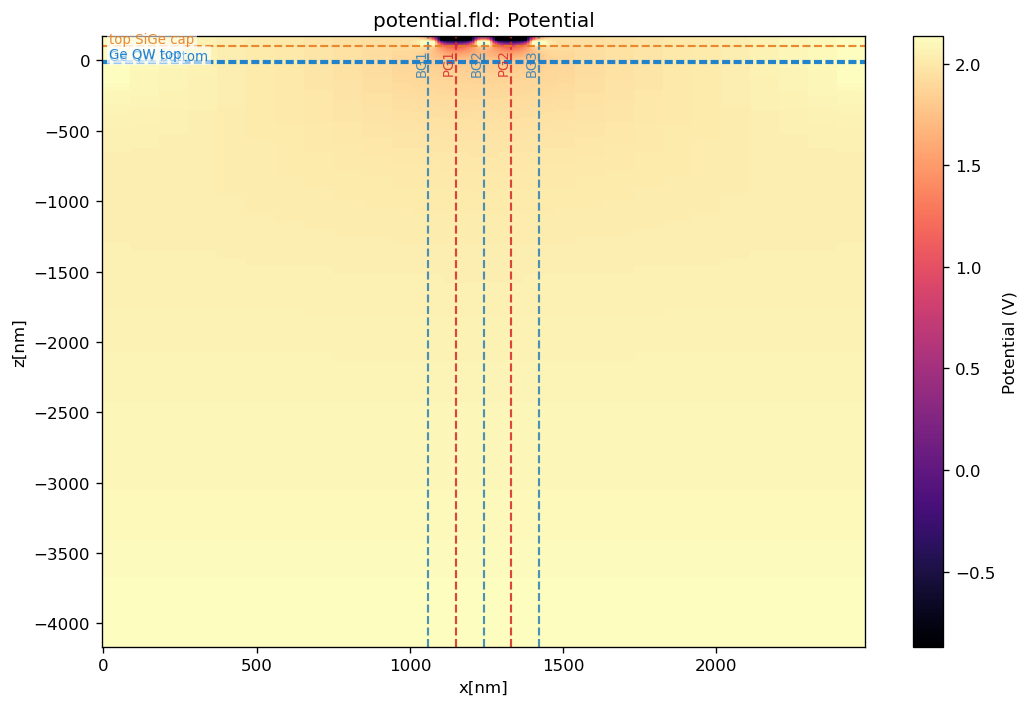

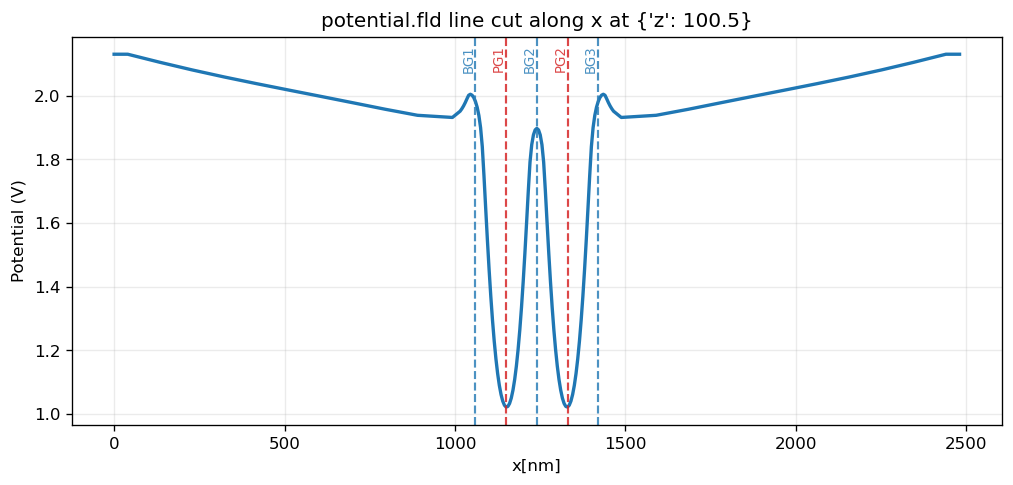

Chosen potential line cut: {'z': 100.5}


In [10]:
potential_line = show_bias_plane_with_linecut(
    RUN_ROOT,
    'potential',
    interactive=INTERACTIVE_PLANES,
    interactive_linecut=INTERACTIVE_LINECUTS,
    line_axis=SURFACE_LINECUT_AXIS,
    line_coords=SURFACE_LINECUT_COORDS,
    bias=BIAS_INDEX,
)
print('Chosen potential line cut:', potential_line['chosen_coords'])


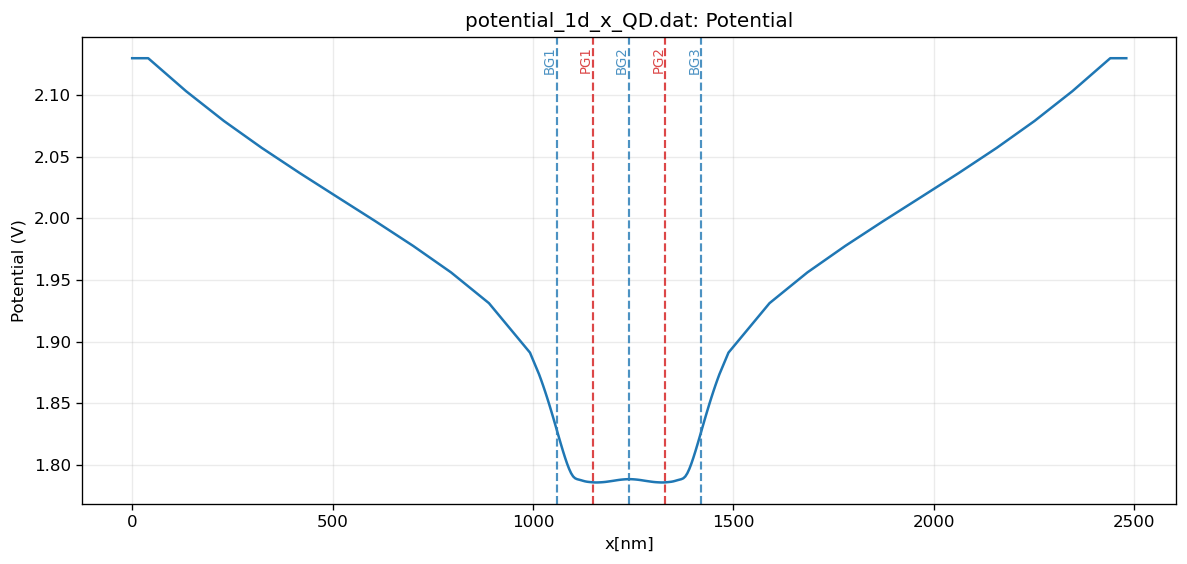

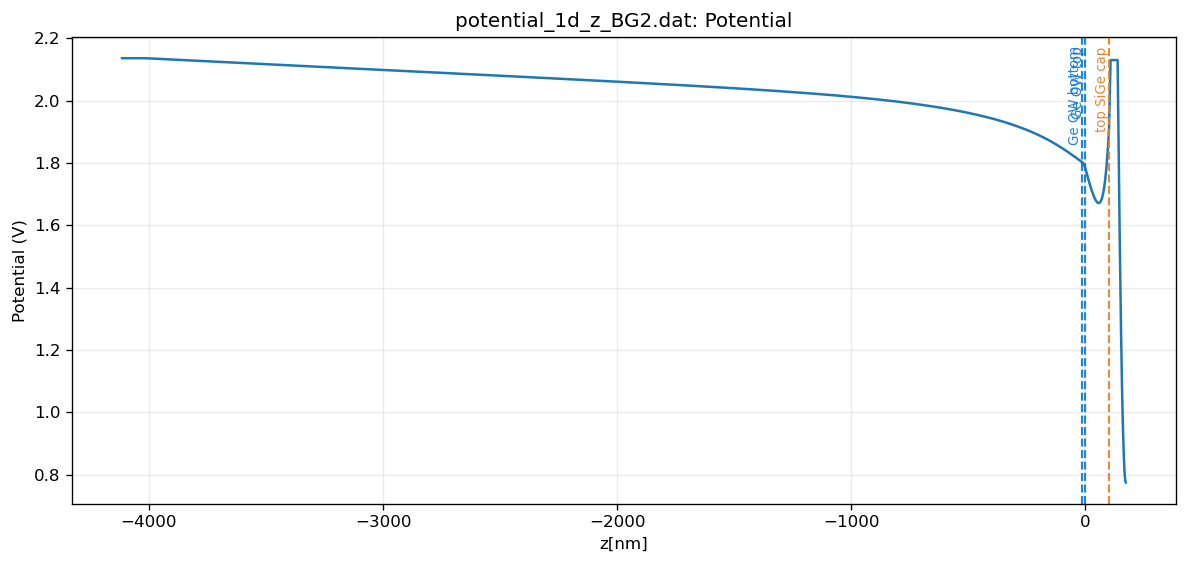

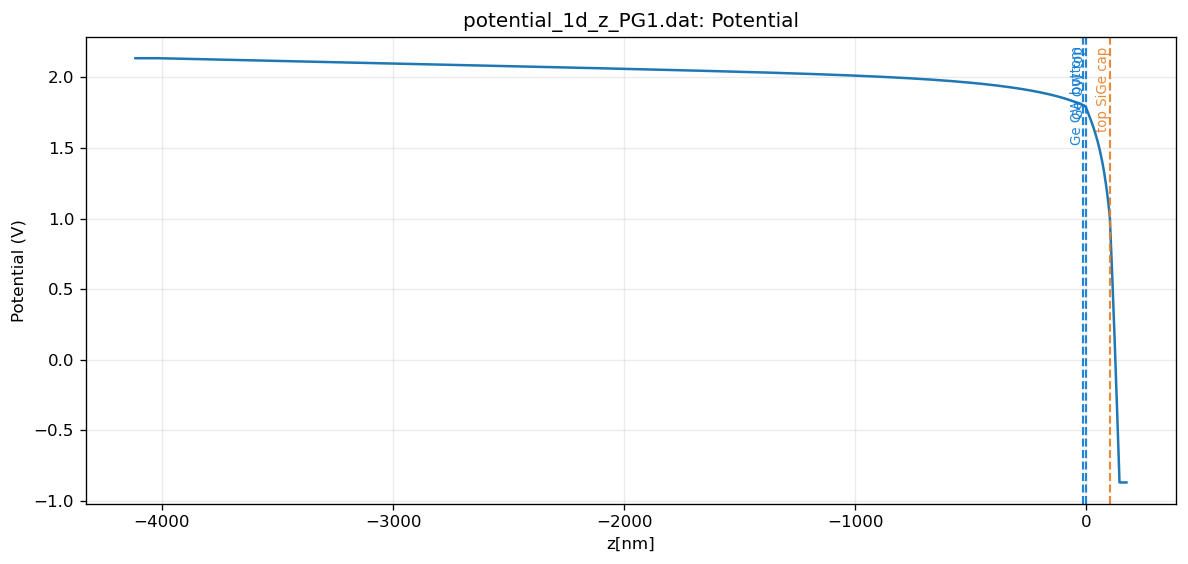

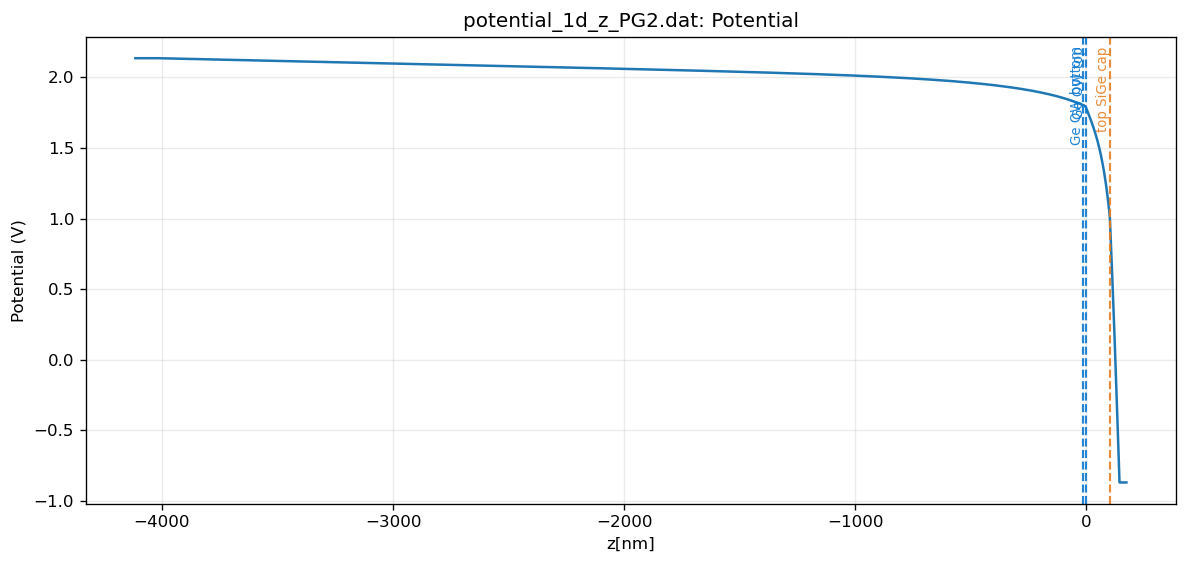

In [11]:
plot_bias_linecuts_for_cuts(
    RUN_ROOT,
    'potential',
    STANDARD_CUTS,
    bias=BIAS_INDEX,
    interactive=INTERACTIVE_LINECUTS,
)


### - Electric field

The field map is often the clearest way to see where the electrostatics are pushing holes toward the oxide interface or back into the well.

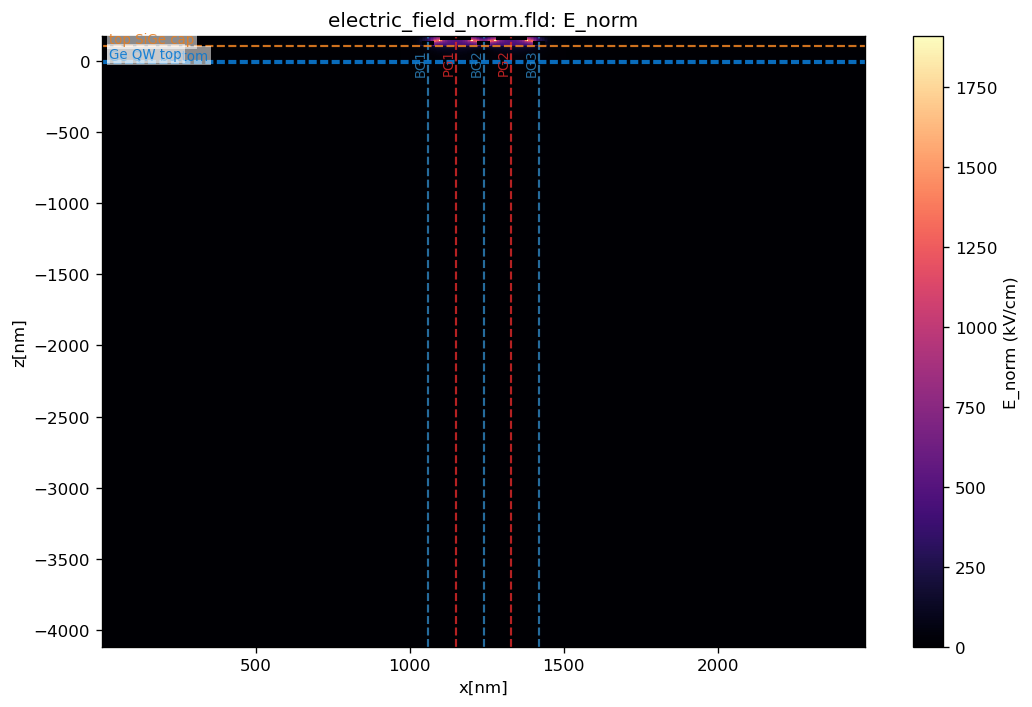

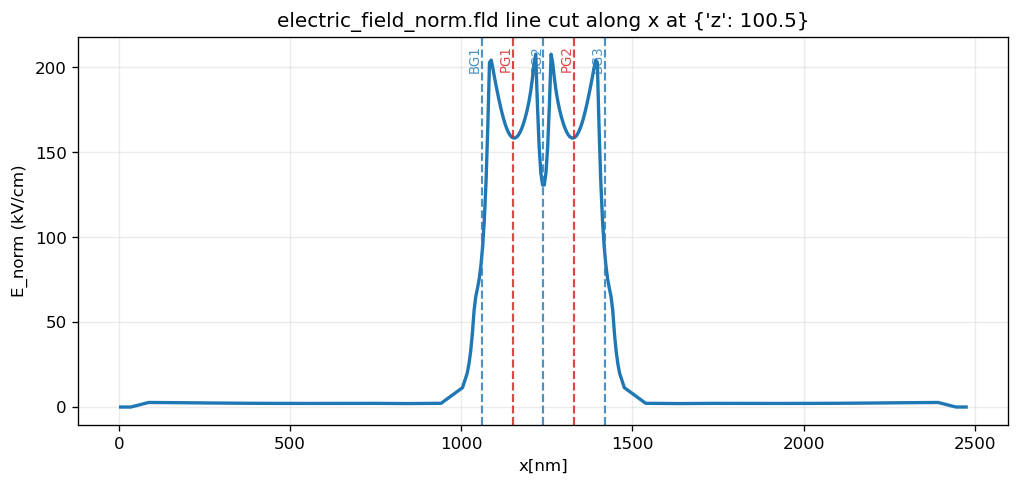

Chosen electric-field line cut: {'z': 100.45}


In [12]:
efield_line = show_bias_plane_with_linecut(
    RUN_ROOT,
    'electric_field_norm',
    interactive=INTERACTIVE_PLANES,
    interactive_linecut=INTERACTIVE_LINECUTS,
    line_axis=SURFACE_LINECUT_AXIS,
    line_coords=SURFACE_LINECUT_COORDS,
    bias=BIAS_INDEX,
)
print('Chosen electric-field line cut:', efield_line['chosen_coords'])


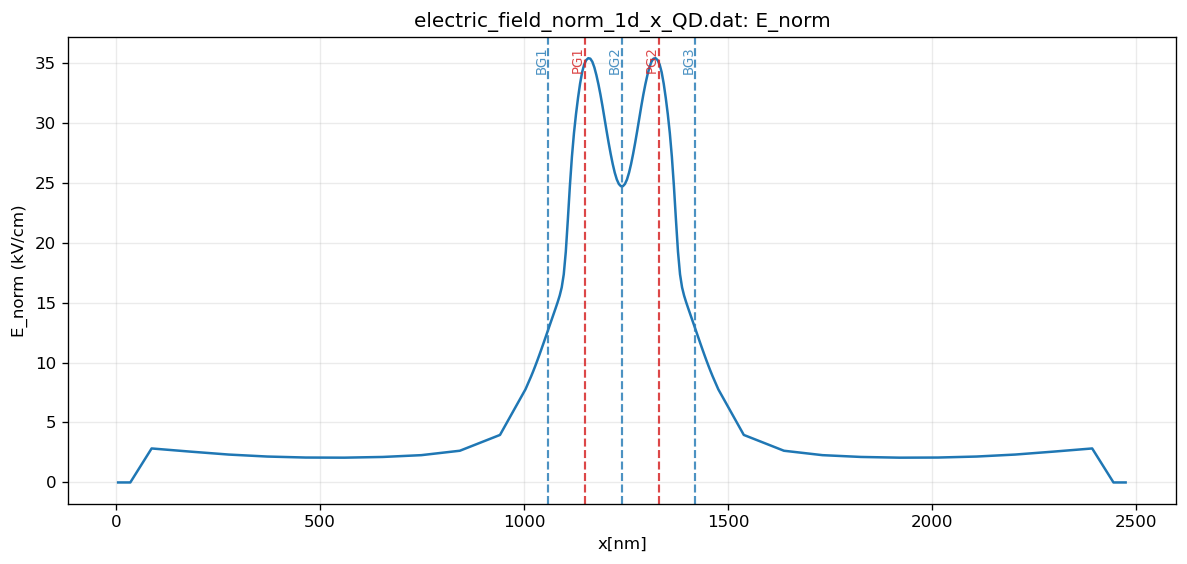

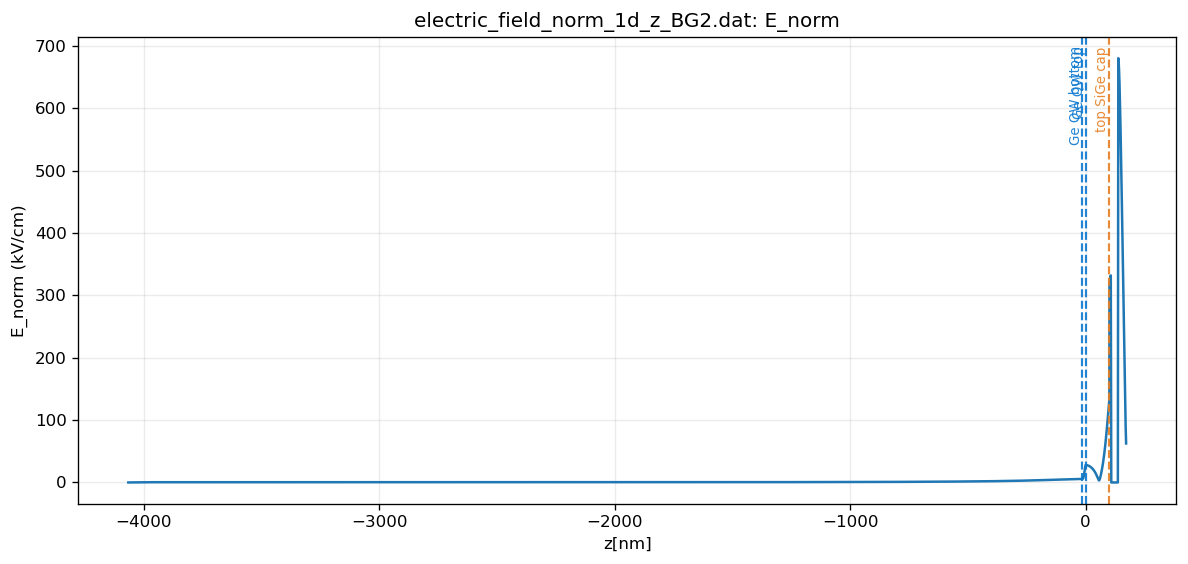

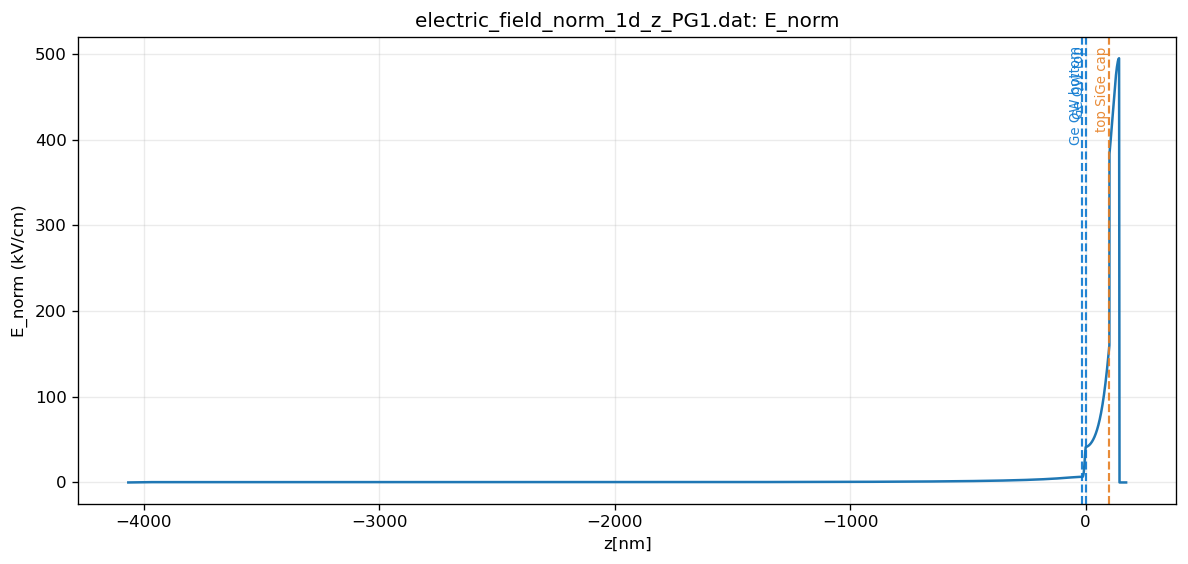

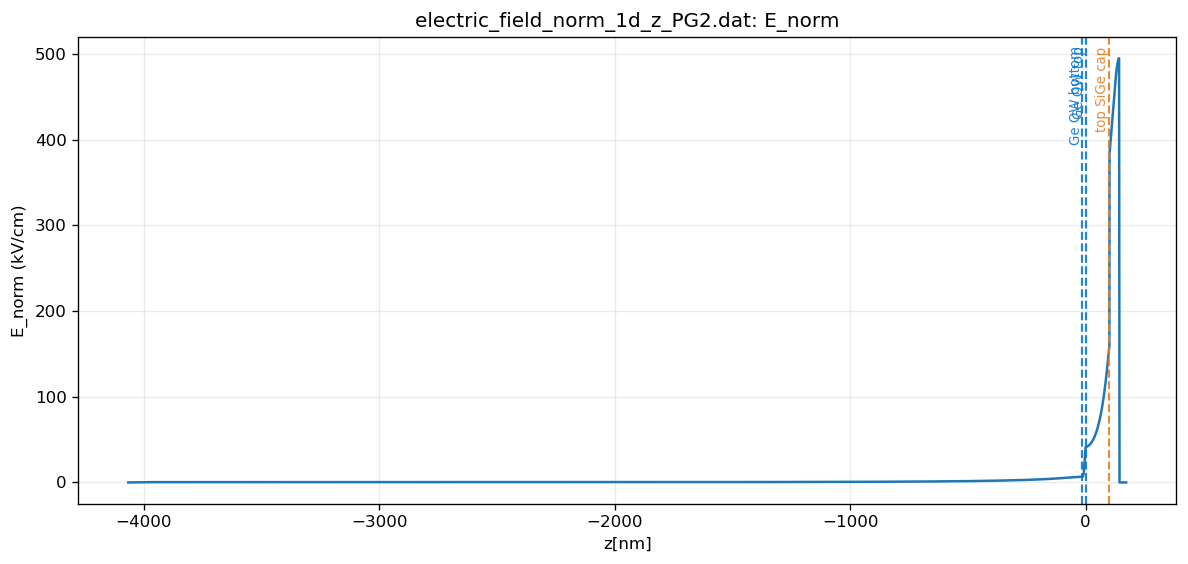

In [13]:
plot_bias_linecuts_for_cuts(
    RUN_ROOT,
    'electric_field_norm',
    STANDARD_CUTS,
    bias=BIAS_INDEX,
    interactive=INTERACTIVE_LINECUTS,
)


### - Carrier density

Focus on the hole density first, since that is the failure mode we are trying to suppress in the cap. The electron density cuts are included only as a sanity check that electrons are not being accumulated unintentionally.

In [53]:
INTERACTIVE_PLANES = True
INTERACTIVE_LINECUTS = False

In [8]:
hole_line = show_bias_plane_with_linecut(
    RUN_ROOT,
    'density_hole',
    interactive=INTERACTIVE_PLANES,
    interactive_linecut=INTERACTIVE_LINECUTS,
    line_axis=SURFACE_LINECUT_AXIS,
    line_coords=SURFACE_LINECUT_COORDS,
    log10=False,
    bias=BIAS_INDEX,
)
print('Chosen hole-density line cut:', hole_line['chosen_coords'])


Chosen hole-density line cut: {'z': 100.5}


In [60]:
plot_bias_linecuts_for_cuts(
    RUN_ROOT,
    'density_hole',
    STANDARD_CUTS,
    # yscale='log',
    bias=BIAS_INDEX,
    interactive=INTERACTIVE_LINECUTS,
)


In [61]:
plot_bias_linecuts_for_cuts(
    RUN_ROOT,
    'density_electron',
    STANDARD_CUTS,
    yscale='log',
    bias=BIAS_INDEX,
    interactive=INTERACTIVE_LINECUTS,
)


### - HH band edge versus Fermi level

This is the core diagnostic for the bias study. Inspect the 2D HH band-edge landscape, then use the selected horizontal line cut near the oxide interface and the standard 1D cuts to see whether the HH edge rises above the hole Fermi level in the SiGe cap.

In [17]:
INTERACTIVE_PLANES = True
INTERACTIVE_LINECUTS = False

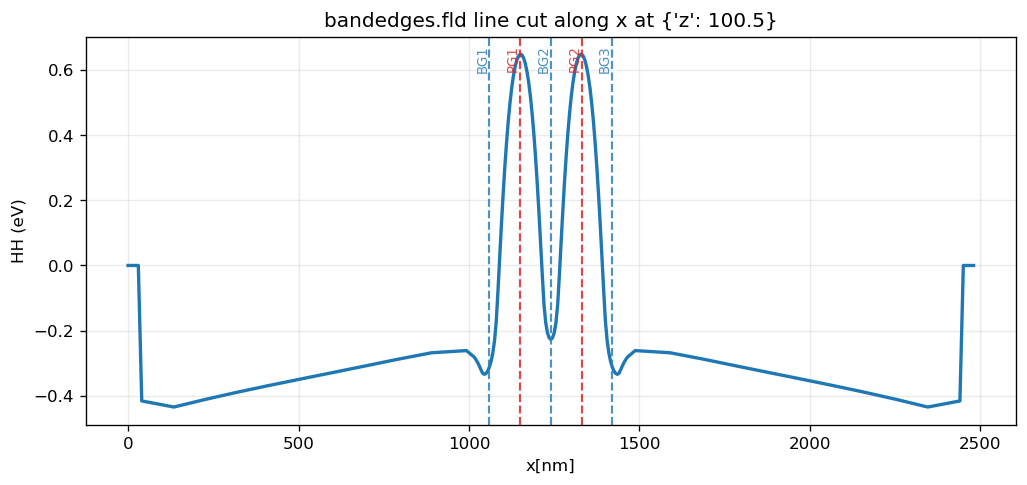

Chosen HH band-edge line cut: {'z': 100.5}


In [18]:
hh_line = show_bias_plane_with_linecut(
    RUN_ROOT,
    'bandedges',
    variable='HH',
    interactive=INTERACTIVE_PLANES,
    interactive_linecut=INTERACTIVE_LINECUTS,
    line_axis=SURFACE_LINECUT_AXIS,
    line_coords=SURFACE_LINECUT_COORDS,
    bias=BIAS_INDEX,
)
print('Chosen HH band-edge line cut:', hh_line['chosen_coords'])


In [ ]:
INTERACTIVE_LINECUTS = True

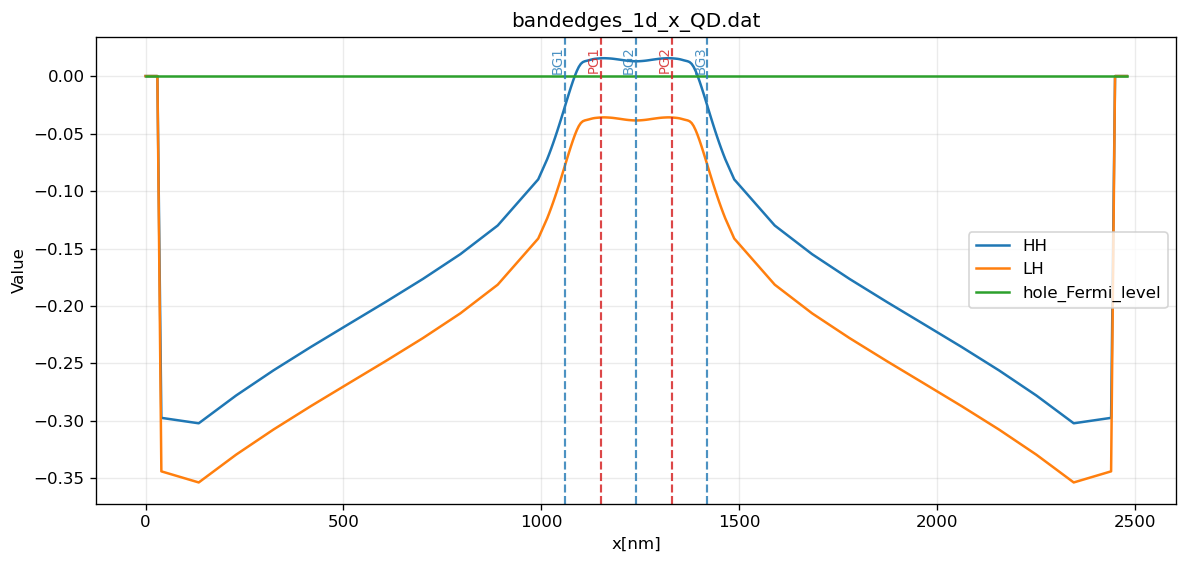

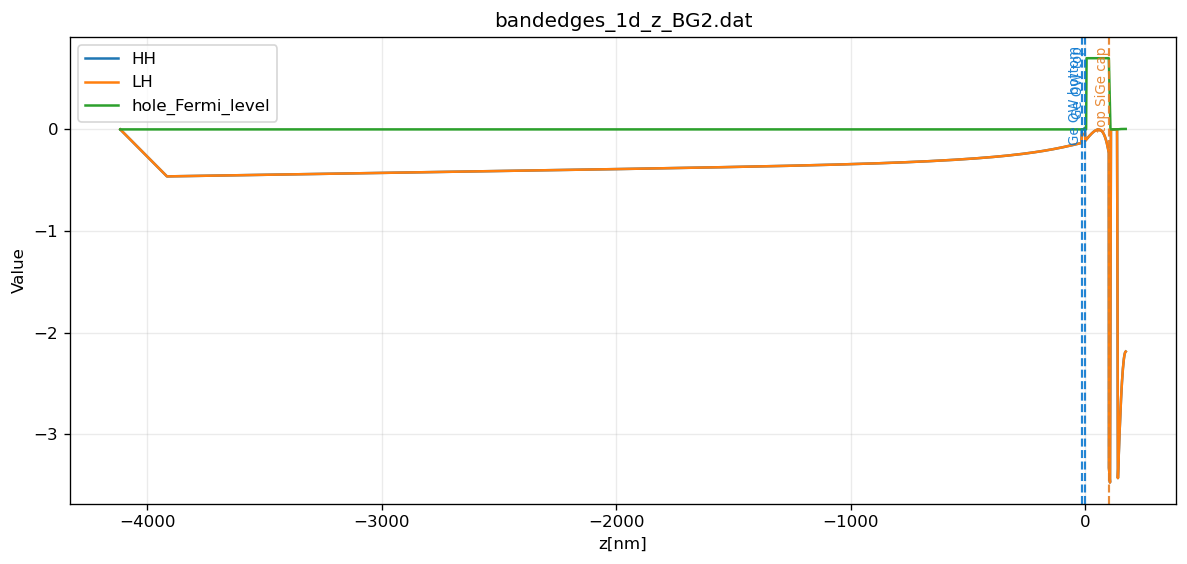

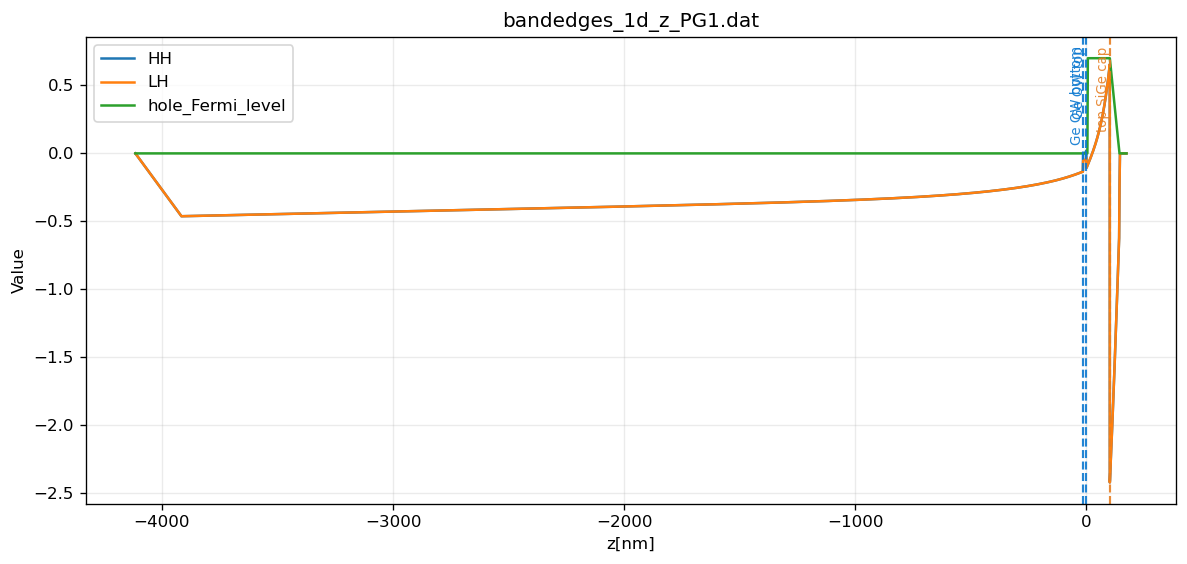

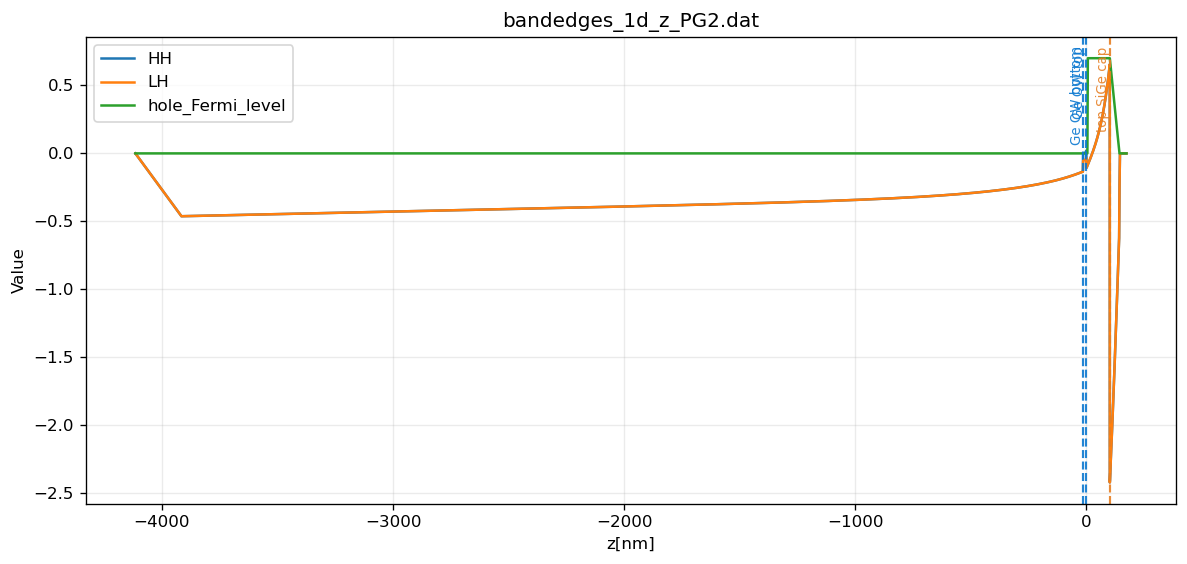

In [19]:
plot_bias_linecuts_for_cuts(
    RUN_ROOT,
    'bandedges',
    STANDARD_CUTS,
    variables=['HH', 'LH', 'hole_Fermi_level'],
    bias=BIAS_INDEX,
    interactive=INTERACTIVE_LINECUTS,
)


### - HH quantum outputs

Use the HH quantum diagnostics in `Quantum/c-Ge_QW/HH` to confirm that the intended charge remains localized in the Ge well while the cap is being emptied by the removed-screening contact.

In [6]:
INTERACTIVE_PLANES = True
INTERACTIVE_LINECUTS = True

In [7]:
quantum_density_line = show_quantum_plane_with_linecut(
    RUN_ROOT,
    quantity='density',
    region=QUANTUM_REGION,
    band=QUANTUM_BAND,
    interactive=INTERACTIVE_PLANES,
    interactive_linecut=INTERACTIVE_LINECUTS,
    line_axis=QW_LINECUT_AXIS,
    line_coords=QW_LINECUT_COORDS,
    log10=False,
    bias=BIAS_INDEX,
)
print('Chosen HH quantum-density line cut:', quantum_density_line['chosen_coords'])


Chosen HH quantum-density line cut: {'z': -4.0}


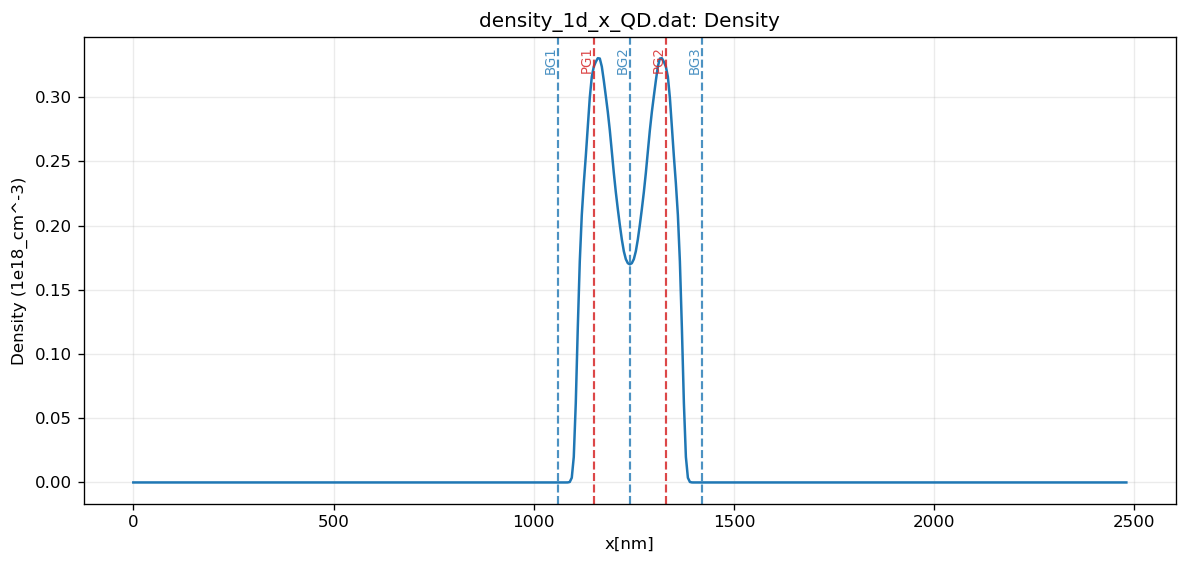

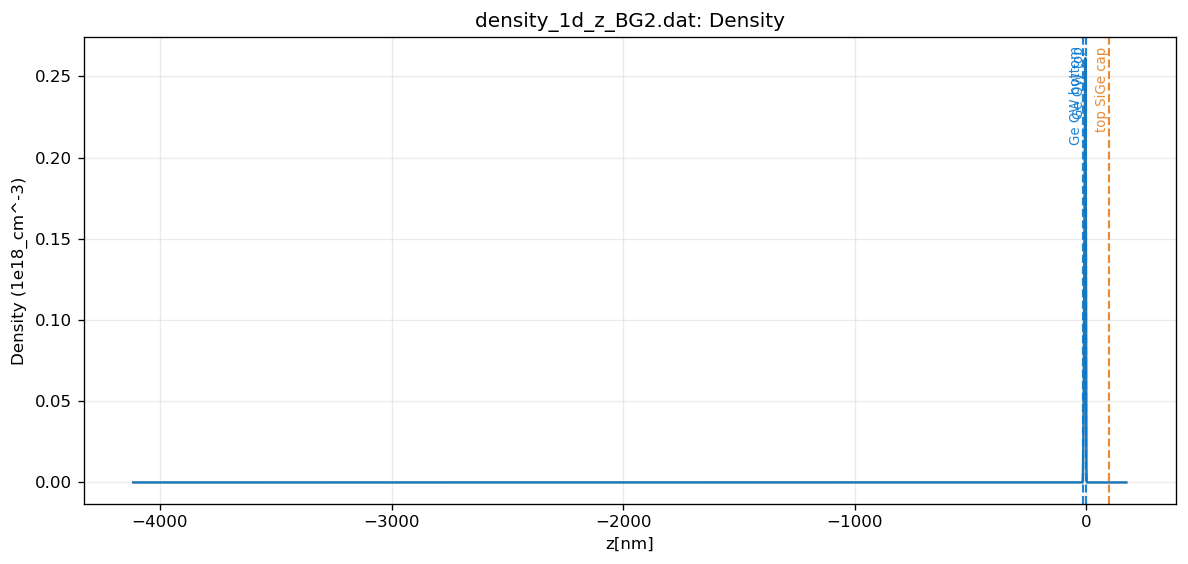

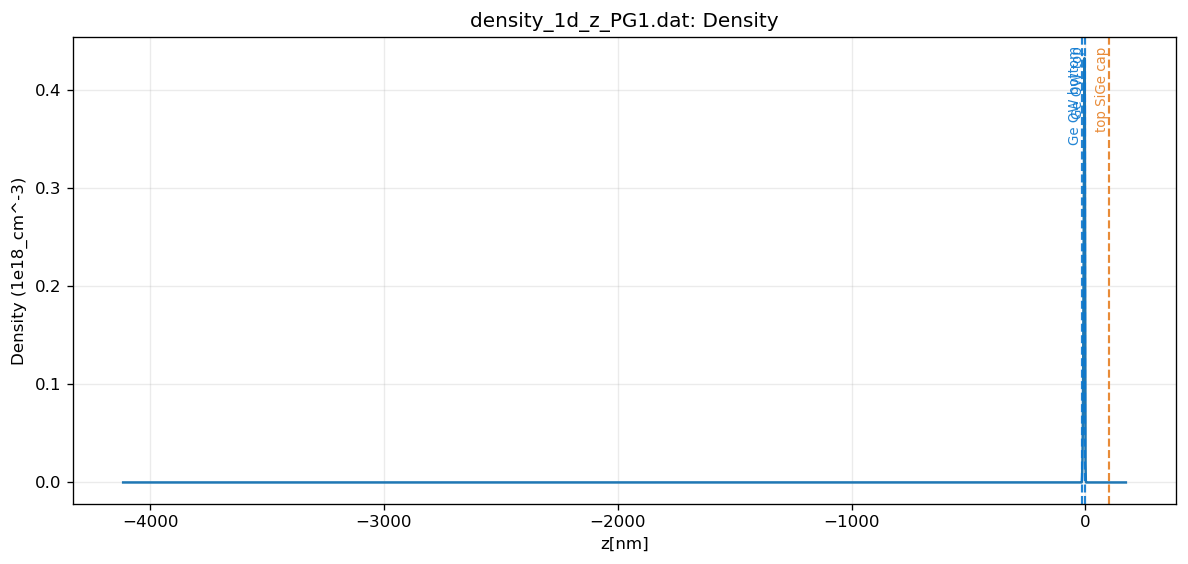

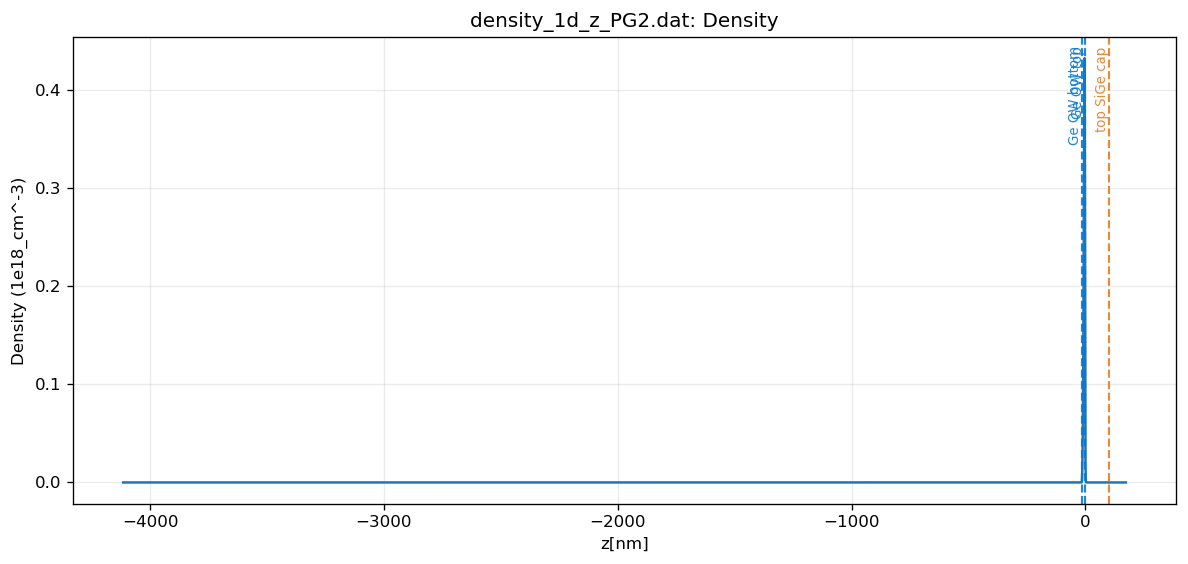

In [21]:
plot_quantum_density_linecuts_for_cuts(
    RUN_ROOT,
    STANDARD_CUTS,
    region=QUANTUM_REGION,
    band=QUANTUM_BAND,
    bias=BIAS_INDEX,
    interactive=INTERACTIVE_LINECUTS,
)


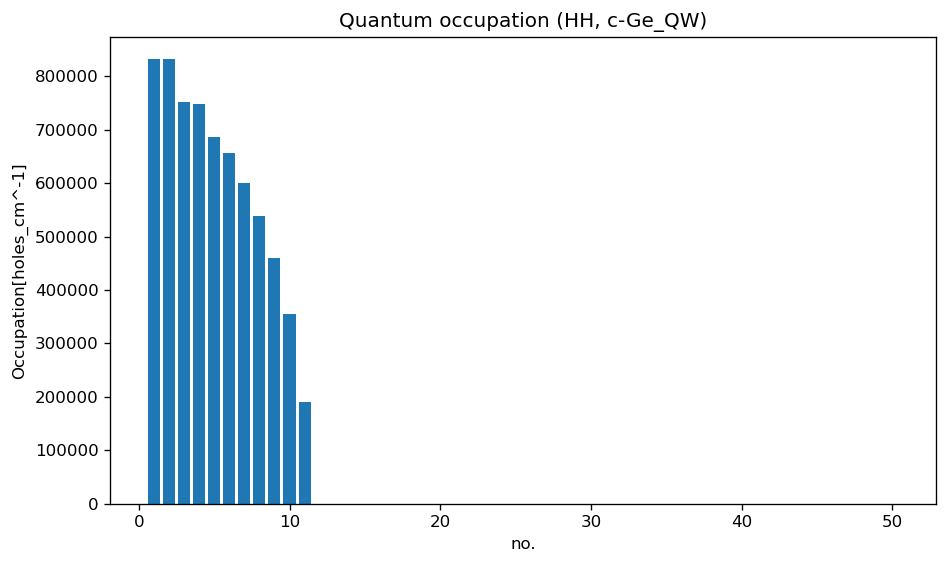

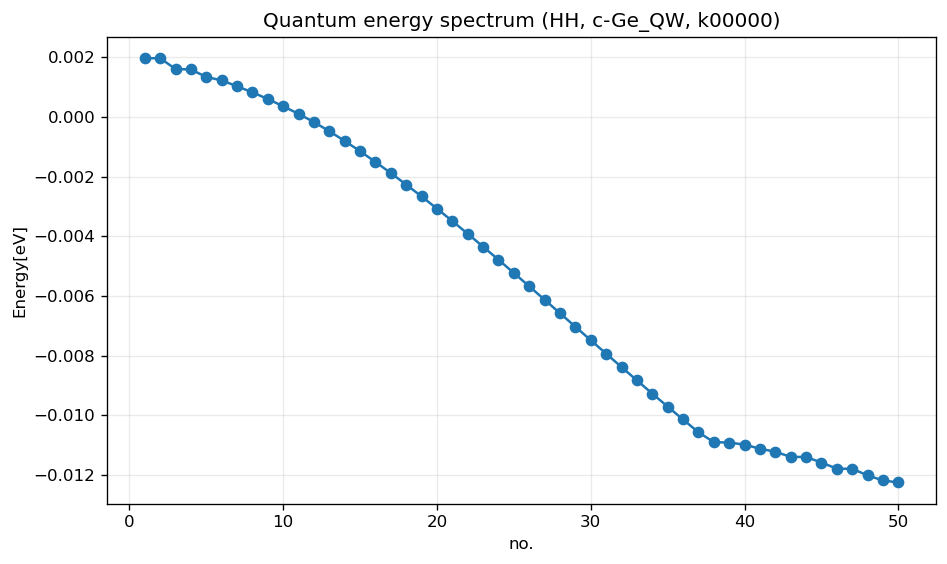

In [22]:
nnt.plot_quantum_occupation(
    RUN_ROOT,
    region=QUANTUM_REGION,
    band=QUANTUM_BAND,
    bias=BIAS_INDEX,
    interactive=False,
)
plt.show()

nnt.plot_quantum_energy_spectrum(
    RUN_ROOT,
    region=QUANTUM_REGION,
    band=QUANTUM_BAND,
    kpoint=QUANTUM_KPOINT,
    bias=BIAS_INDEX,
    interactive=False,
)
plt.show()


In [11]:
INTERACTIVE_PLANES = False
INTERACTIVE_LINECUTS = False
QUANTUM_PROBABILITY_STATE = 1

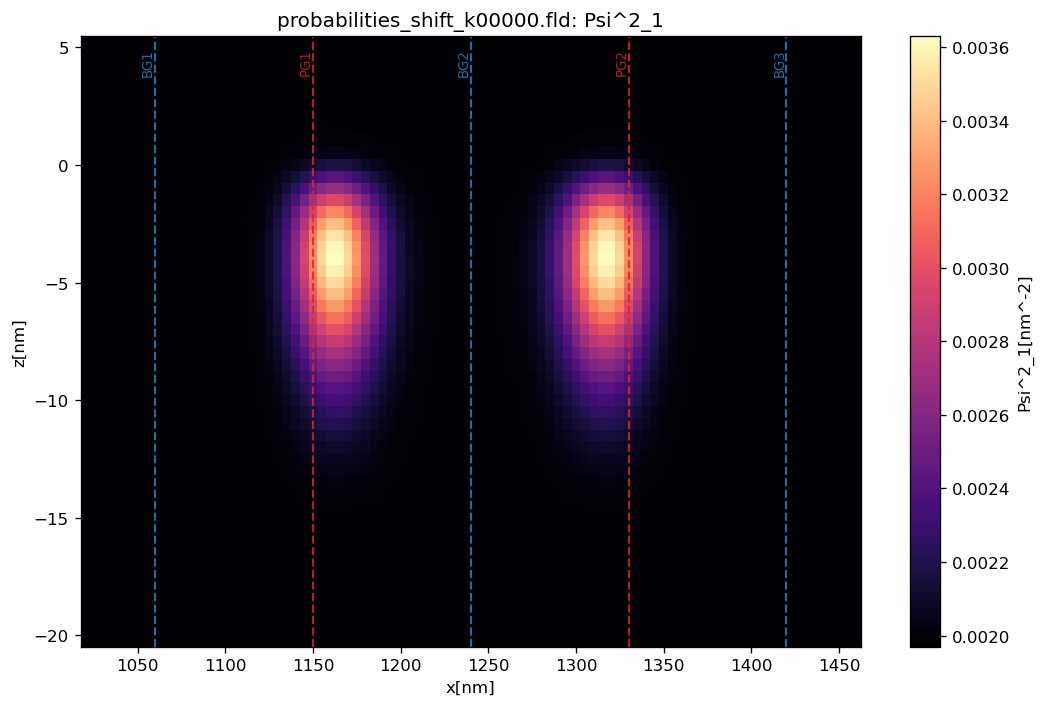

In [12]:
nnt.plot_quantum_probability_plane(
    RUN_ROOT,
    state=QUANTUM_PROBABILITY_STATE,
    region=QUANTUM_REGION,
    band=QUANTUM_BAND,
    kpoint=QUANTUM_KPOINT,
    bias=BIAS_INDEX,
    interactive=INTERACTIVE_PLANES,
    x_markers=markers_for_axis('x'),
    # y_markers=markers_for_axis('z'),
)
if not INTERACTIVE_PLANES:
    plt.show()


In [15]:
QUANTUM_PROBABILITY_STATES = {1,2,3,4,5}
INTERACTIVE_LINECUTS = True

In [16]:
plot_quantum_probability_linecuts_for_cuts(
    RUN_ROOT,
    STANDARD_CUTS,
    states=QUANTUM_PROBABILITY_STATES,
    region=QUANTUM_REGION,
    band=QUANTUM_BAND,
    kpoint=QUANTUM_KPOINT,
    bias=BIAS_INDEX,
    interactive=INTERACTIVE_LINECUTS,
)
